## Load Data

In [27]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import gc
from pathlib import Path
import sys
PROJECT_ROOT = Path("/home/jovyan/work/MST")
sys.path.append(str(PROJECT_ROOT))

from mst_xai.evaluation_methods.perturbation_core_code.perturbation_core import perturbation_evaluation
from mst.data.datasets.dataset_3d_odelia import ODELIA_Dataset3D
from mst.inference.predictor import load_model
from mst_xai.utils.load_saliency import load_saliency




In [28]:
import pickle
with open("uid_to_index.pkl", "rb") as f:
    uid_to_index = pickle.load(f)

In [29]:
ds = ODELIA_Dataset3D(
    path_root="/home/jovyan/work/MST/mst/data/datasets/ODELIA_datasets",
    split="test"
)

In [30]:
example_uid = "ODELIA_TRICKS_0067_1_left"
example_index = uid_to_index[example_uid]
print(f"Example UID: {example_uid}, Index: {example_index}")

Example UID: ODELIA_TRICKS_0067_1_left, Index: 1


In [31]:
run_dir = Path("/home/jovyan/work/MST/runs")

## For DINOv2
# run_folder = Path("DINOv2ViTS/DinoV2ClassifierSlice_Final")
# path_run = run_dir / run_folder

##For New Model
run_folder = Path("DINOv3ViTB")
checkpoint_name = "challenge_mstv3-vit_sch_CB_sub2_best.chkpt"
path_run = run_dir / run_folder / checkpoint_name

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("DinoV2ClassifierSlice", path_run, device)
model.to(device)
model.eval()

Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dinov3_main


DinoV2ClassifierSlice(
  (loss_func): CrossEntropyLoss()
  (auc_roc): ModuleDict(
    (train_): MulticlassAUROC()
    (val_): MulticlassAUROC()
    (test_): MulticlassAUROC()
  )
  (acc): ModuleDict(
    (train_): MulticlassAccuracy()
    (val_): MulticlassAccuracy()
    (test_): MulticlassAccuracy()
  )
  (encoder): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): Layer

In [32]:
sample = ds[example_index]
gt = sample["target"]
batch = {
    "source": sample["source"].unsqueeze(0).to(device),
    "target": torch.tensor([gt], device=device)
}

In [33]:
with torch.no_grad():
    logits = model(batch["source"])
    probs = torch.softmax(logits, dim=-1)

pred_class = probs.argmax(dim=1).item()

print("Predicted class:", pred_class)

Predicted class: 2


In [37]:
saliency_map = "gradcam"
label = "2"
uid = example_uid
# Example: Grad-CAM / Attention rollout etc.
saliency_path = (
    f"/home/jovyan/work/MST/results/DINOv3ViTB/saliency_results/"
    f"{saliency_map}/class_{label}/pt/{uid}_importance.pt"
)

saliency_path = Path(saliency_path)
sal = load_saliency(saliency_path, device=device)
# sal = torch.load(saliency_path, map_location="cpu", weights_only=True)

In [36]:
def run_single_mode(mode, slice_index):

    replacements = {
        "black-5": "Black Masking",
        "minimum-intensity": "Minimum Intensity",
        "white-5": "White Masking",
        "gaussian_blur": "Gaussian Blur",
        "attention_mask": "Attention Mask"
    }

    results = {}

    for rep, name in replacements.items():
        out = perturbation_evaluation(
            model=model,
            batch=batch,
            saliency=sal,
            predicted_class=pred_class,
            patch_size=16,
            steps=20,
            mode=mode,
            replacement=rep,
            return_images=True,
            slice_index=slice_index
        )

        results[name] = {
            "images": out[5],
            "auc": out[4]
        }

        print(f"{mode} | {name} | AUC: {out[4]:.4f}")

    return results

In [40]:
def plot_mode(results, title,source):

    steps = 20
    step_ids = [0, 4, 8, 12, 16, 20]

    reps = list(results.keys())

    fig, axes = plt.subplots(len(reps), len(step_ids), figsize=(15, 10))

    vmin = source.min().item()
    vmax = source.max().item()    

    for i, rep in enumerate(reps):
        imgs = results[rep]["images"]

        for j, s in enumerate(step_ids):
            ax = axes[i, j]


            ax.imshow(imgs[s], cmap="gray", vmin=vmin, vmax=vmax)
            ax.axis("off")

            # column titles (top row only)
            if i == 0:
                ax.set_title(f"{int(s/steps*100)}%", fontsize=11)

    for i, rep in enumerate(reps):
        axes[i, 0].annotate(
            rep,
            xy=(-0.35, 0.5),  # move left of grid
            xycoords='axes fraction',
            va='center',
            ha='right',
            fontsize=12,
            rotation=0
        )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"/home/jovyan/work/MST/scripts/Jupyter_notebook/Perturbation visualization/{title}.jpg", dpi =100)
    plt.show()

deletion | Black Masking | AUC: 0.0849
deletion | Minimum Intensity | AUC: 0.1214
deletion | White Masking | AUC: 0.2716
deletion | Gaussian Blur | AUC: 0.4955
deletion | Attention Mask | AUC: 0.1676


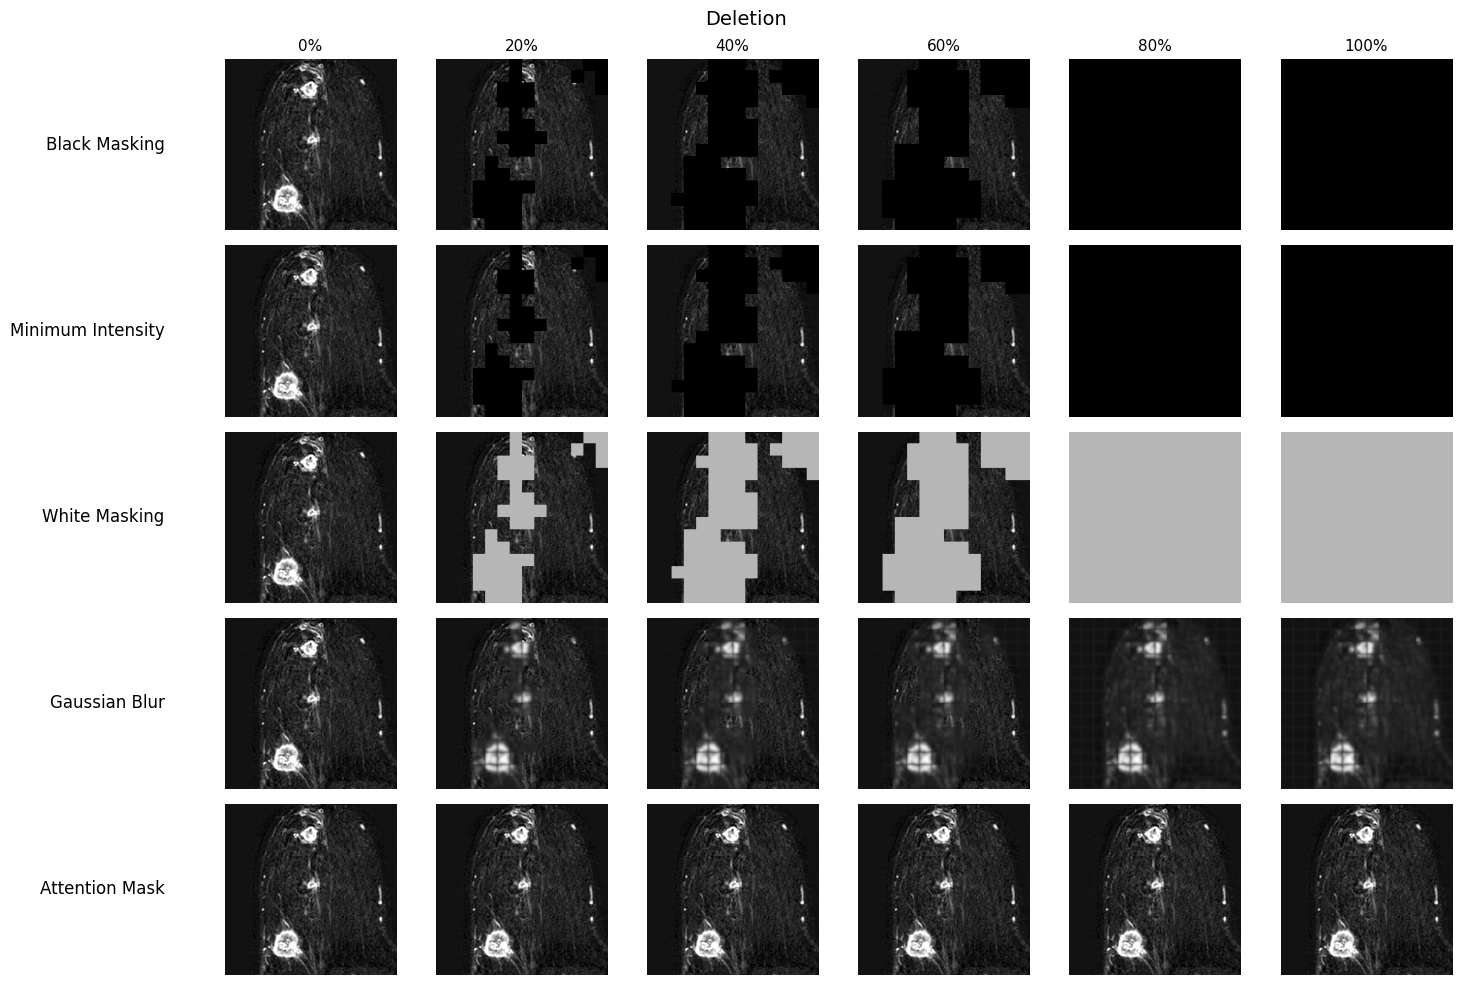

In [41]:
del_results = run_single_mode("deletion", slice_index=10)
plot_mode(del_results, "Deletion", batch["source"])

insertion | Black Masking | AUC: 0.6102
insertion | Minimum Intensity | AUC: 0.9537
insertion | White Masking | AUC: 0.9136
insertion | Gaussian Blur | AUC: 0.8174
insertion | Attention Mask | AUC: 0.9468


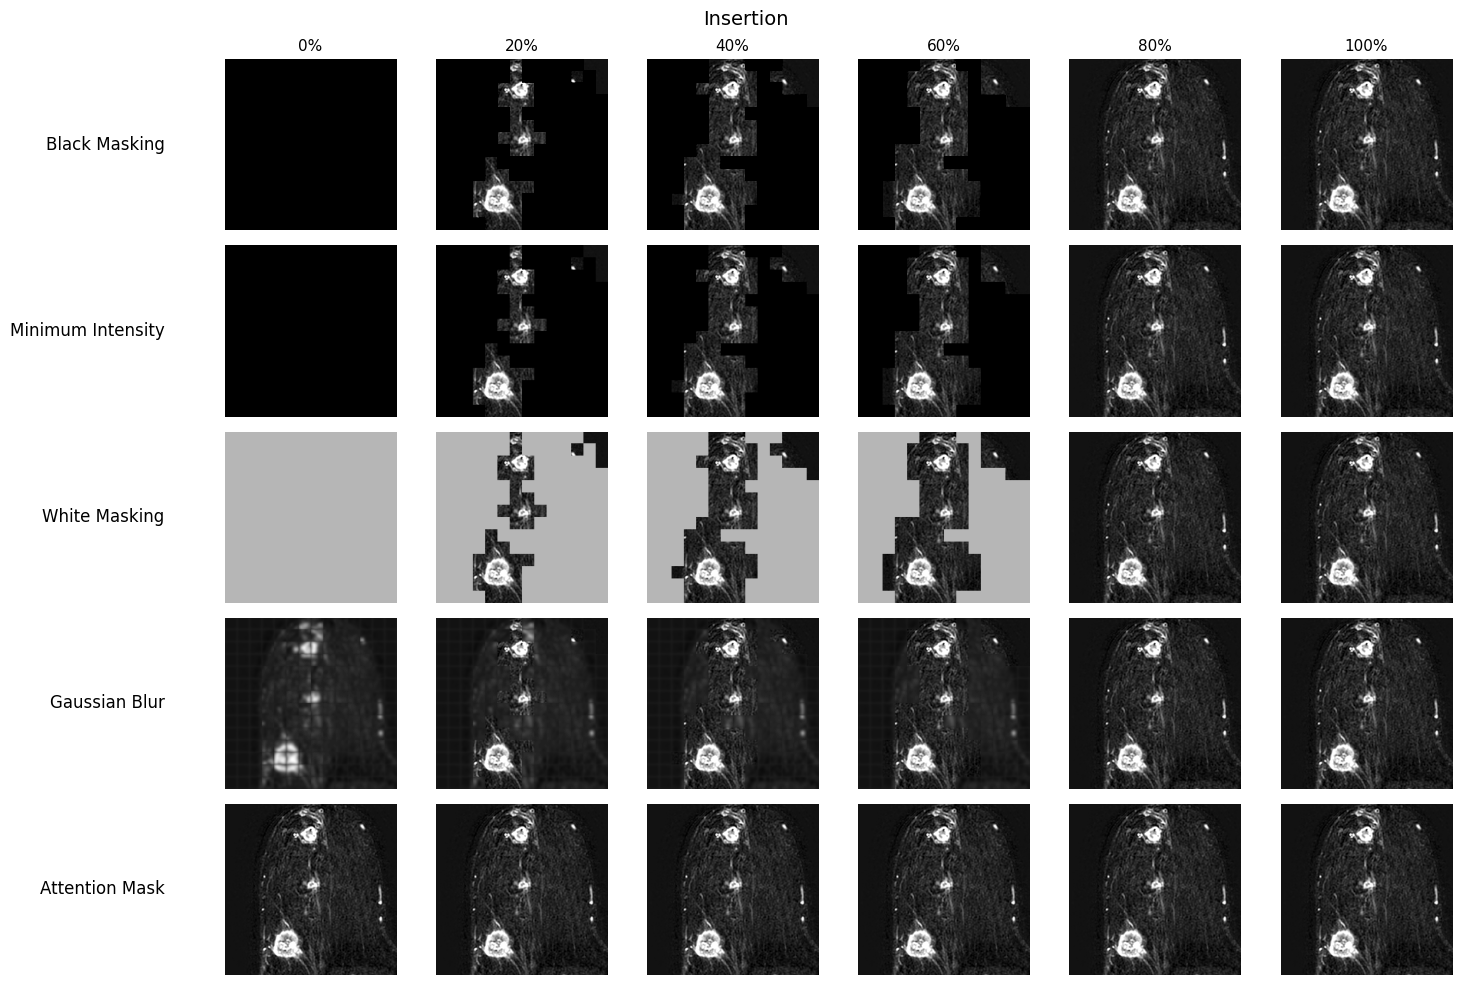

In [42]:
ins_results = run_single_mode("insertion", slice_index=10)
plot_mode(ins_results, "Insertion", batch["source"])

negative | Black Masking | AUC: 0.5753
negative | Minimum Intensity | AUC: 0.9555
negative | White Masking | AUC: 0.9157
negative | Gaussian Blur | AUC: 0.8255
negative | Attention Mask | AUC: 0.9467


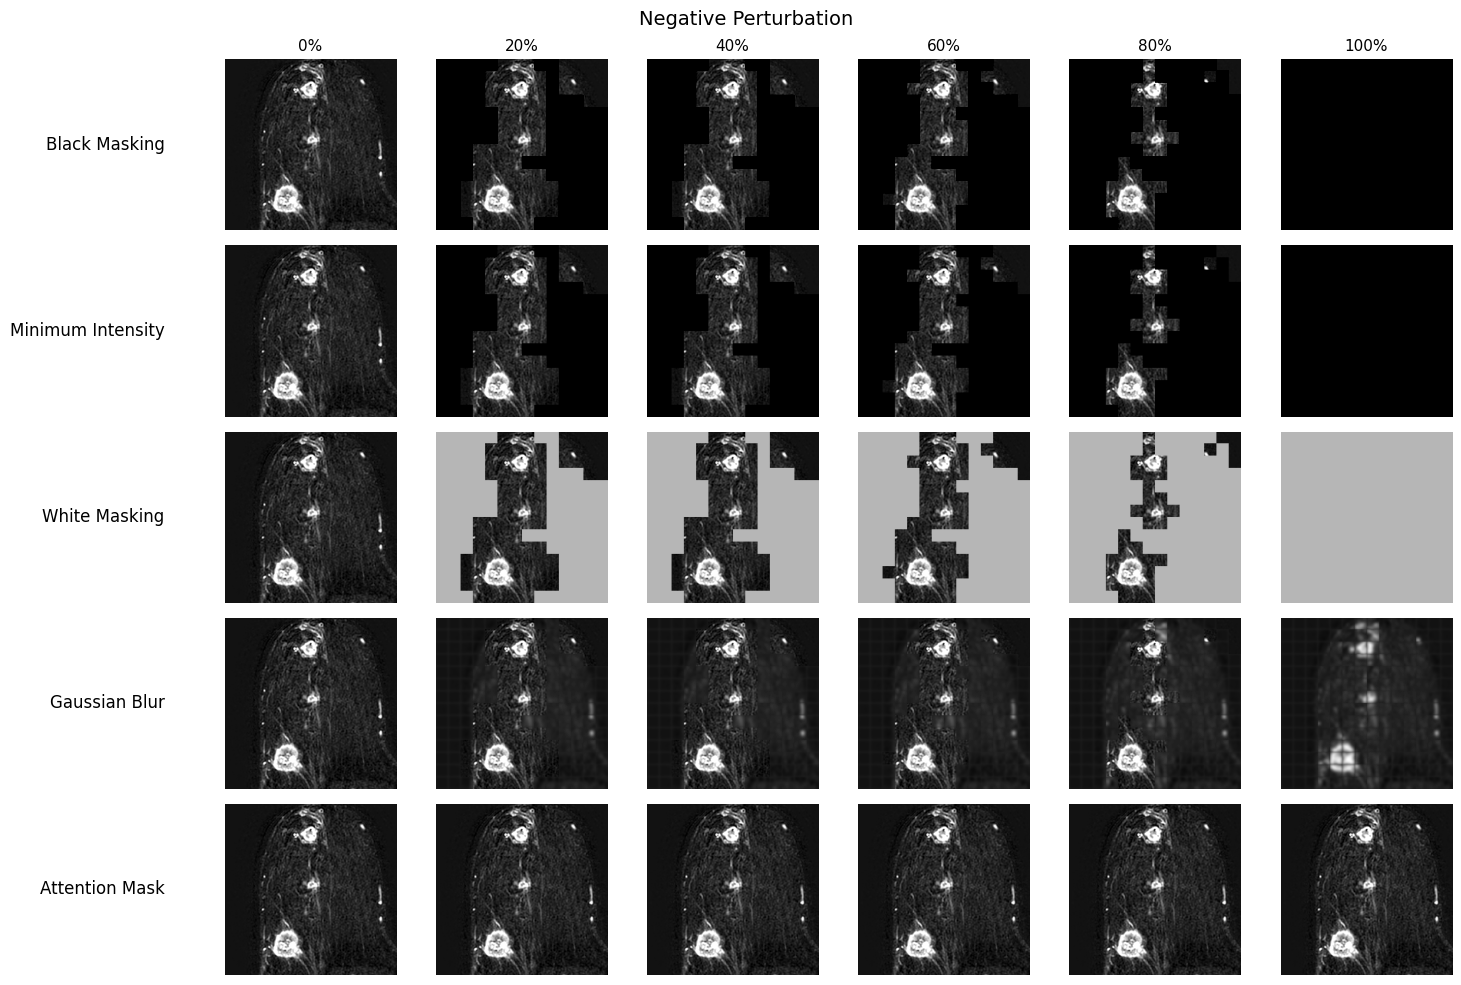

In [43]:
neg_results = run_single_mode("negative", slice_index=10)
plot_mode(neg_results, "Negative Perturbation", batch["source"])